# Consensus vs LLM judges on fresh logic data (E2-A) — demo

**Question.** Can a gold-free metric tell whether a candidate first-order-logic (FOL) formalization of an English sentence is
*faithful* to the sentence? This artifact is the pre-registered confirmation test of the frozen **cross-family solver
consensus** score **V0 = `c_score_align`** on a fresh NL→FOL set (E2) that no earlier experiment had seen.

**What V0 measures.** For a candidate formula of a sentence, V0 = 1 − (share of *parseable peer formalizations of the same
sentence, written by other model families*, that z3 proves equivalent to the candidate after a predicate/constant vocabulary
alignment). Higher means more likely an **ERROR**. It needs no gold formula.

**What the full run did** (`method.py` is a stage orchestrator; the stages call separate scripts):
1. label-free scoring of all 5,500 candidates (550 sentences × 10 LLM slots): V0, `c_exact`, peer-text fusion PT, variants
   V1–V5, text-side checks L2/L3, the user's pilot structural metrics, a local Qwen3-8B judge, and API judges;
2. **sealing** every score (sha256) *before* labels were joined;
3. labels from a prover-built reference (tier A/B) and a panel; the panel budget ran out, so only a 110-sentence random prefix
   is labelled;
4. meta-evaluation: within-stratum AUROC with stratified sentence-cluster bootstrap CIs, a shuffled-label placebo, and rename
   invariance controls.

**What this notebook runs.** Steps 1–3 need paid API calls, a GPU judge, private virtualenvs and ~35k lines of frozen solver
code, so their **sealed outputs** are loaded from `mini_demo_data.json`. The notebook then re-runs step 4 — the actual
meta-evaluation code of `analysis/analyse_E2A.py`, the frozen `stats.py` and the independent audit `audit/rederive.py` — on a
curated subset of **93 labelled candidates from 11 whole sentences** (strata: `DT` = short deductive-template sentences,
`L25` = long sentences ≥25 words, `EXC` = sentences with exceptions). Numbers on this subset are therefore noisier than the
full-run numbers (273 rows / 110 sentences), which are shown alongside for comparison.

**Headline of the full run:** V0 tracks correctness (ALL 0.890 strat. AUROC) but only *ties* a local 8B LLM judge
(DT delta +0.003, CI includes 0), adds nothing over a judge stack, and is **not rename-invariant** (renamed correct formulas are
flagged 94–100% of the time). The user's pilot structural metrics sit at ≈0.5 AUROC, i.e. they do not track correctness.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# All packages used here are pre-installed on Colab -> install locally only, at Colab's exact versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')

In [2]:
# --- original method.py imports ---
from __future__ import annotations

import argparse
import os
import subprocess
import sys
from pathlib import Path

# --- analysis/analyse_E2A.py + frozen eval-2 stats.py imports ---
import hashlib
import json
import math
import time
from collections import Counter, defaultdict

import numpy as np
from scipy.stats import rankdata

# --- audit/rederive.py imports ---
import random, collections
from sklearn.metrics import roc_auc_score

# --- notebook additions (tables / plots) ---
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-eff060-layered-gold-free-checks-for-logic/fork/run_An1uy2kF2SjZ/round-5/experiment-11/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["description"])
print(f"{data['n_rows']} labelled candidate rows from {data['n_sentences']} sentences; "
      f"{len(data['rename_controls'])} rename-control rows")

E2-A NL->FOL meta-evaluation subset: labelled LLM candidate formalizations (R_AB regime: tier A/B prover-built or audited labels, no reading-choice rows) from the 110-sentence random prefix. Every score is label-free, sealed BEFORE labels, and oriented higher = more likely ERROR.
93 labelled candidate rows from 11 sentences; 181 rename-control rows


## Configuration

All tunable parameters. The analysis stage is cheap, so the notebook runs at the **original** values: `B = 2000` bootstrap
replicates (analysis) and `200` shuffled-label placebo replicates (audit), about 15 s in total. Lower them (e.g. `B = 10`,
`N_PLACEBO = 5`) for a quick smoke test.

In [5]:
B = 2000           # stratified sentence-cluster bootstrap replicates   (original value; demo tested 10 -> 200 -> 2000)
N_PLACEBO = 200    # shuffled-label placebo replicates                   (original value; demo tested 5 -> 50 -> 200)
SEED = 0           # bootstrap / placebo seed                            (original: 0)
PREFIX = 110       # labelled sentence prefix of method.py --prefix     (original: 110; the demo data is a subset of it)
LONG = ("L25", "EXC")          # the long, heavily conditioned strata the user cares most about
PRIMARY = "c_score_align"      # V0, the frozen primary consensus score

## 1. The orchestrator: `method.py` stages (dry run)

This is the original `method.py`. Each stage is a subprocess with its own virtualenv (`env/`, a GPU env for the local Qwen3-8B
judge, and the label-side `e2src/` env). The paid stages (panel labels, API judges) are cached and never re-billed. In this
notebook we only **list** the stages instead of executing them — their outputs are the sealed scores and labels in
`mini_demo_data.json`. `WS` is set to the notebook's directory instead of `Path(__file__)` (a notebook has no `__file__`).

In [6]:
WS = Path(".").resolve()   # original: Path(__file__).resolve().parent
PY = str(WS / "env" / ".venv" / "bin" / "python")
GPU = "/root/e2a_gpu/.venv/bin/python"
E2PY = str(WS / "e2src" / ".venv" / "bin" / "python")


def stages(prefix: int) -> list[tuple[str, list[str], Path]]:
    s = [("l3", [PY, "scoring/score_consensus.py", "--stage", "l3"], WS),
         ("consensus", [PY, "scoring/score_consensus.py", "--stage", "score", "--workers", "30"], WS),
         ("pairwise", [PY, "scoring/score_consensus.py", "--stage", "pairwise", "--workers", "36"], WS),
         ("exact", [PY, "scoring/score_consensus.py", "--stage", "exact", "--workers", "36"], WS),
         ("prep", [PY, "scoring/api_judges.py", "--stage", "prep", "--workers", "10"], WS),
         ("judges", [PY, "scoring/api_judges.py", "--stage", "judges", "--concurrency", "32"], WS),
         ("local_judge", [GPU, "scoring/local_judge.py", "--which", "qwen8b_disg,qwen8b_orig", "--bs", "64"], WS),
         ("pilot", [PY, "scoring/pilot_metrics_E2.py"], WS),
         ("assemble", [PY, "scoring/assemble_scores.py"], WS)]
    s += [(f"labels:{x}", [E2PY, f"src_e2/{x}.py"], WS / "e2src")
          for x in ("assemble_e2", "controls_e2", "testability_e2", "seal_e2", "verify_seal")]
    s += [("join", [PY, "analysis/analyse_E2A.py", "--stage", "join"], WS),
          ("analyse", [PY, "analysis/analyse_E2A.py", "--stage", "analyse"] + (["--prefix", str(prefix)] if prefix else []), WS),
          ("rename", [PY, "analysis/rename_V0.py"], WS),
          ("union", [PY, "analysis/union_E2B.py", "--deadline-utc", "2026-09-24T15:40:00Z", "--once"], WS),
          ("outputs", [PY, "analysis/make_outputs.py"], WS)]
    return s


# original main() runs: subprocess.run(cmd, cwd=cwd, env=env, check=True) for every stage from --from onwards.
# Dry run here: print what would execute. The 'join' / 'analyse' / 'rename' stages are what the cells below re-run in-notebook.
for name, cmd, cwd in stages(PREFIX):
    print(f"== {name:<22} {' '.join(Path(c).name if c.startswith('/') else c for c in cmd[1:])}")

== l3                     scoring/score_consensus.py --stage l3
== consensus              scoring/score_consensus.py --stage score --workers 30
== pairwise               scoring/score_consensus.py --stage pairwise --workers 36
== exact                  scoring/score_consensus.py --stage exact --workers 36
== prep                   scoring/api_judges.py --stage prep --workers 10
== judges                 scoring/api_judges.py --stage judges --concurrency 32
== local_judge            scoring/local_judge.py --which qwen8b_disg,qwen8b_orig --bs 64
== pilot                  scoring/pilot_metrics_E2.py
== assemble               scoring/assemble_scores.py
== labels:assemble_e2     src_e2/assemble_e2.py
== labels:controls_e2     src_e2/controls_e2.py
== labels:testability_e2  src_e2/testability_e2.py
== labels:seal_e2         src_e2/seal_e2.py
== labels:verify_seal     src_e2/verify_seal.py
== join                   analysis/analyse_E2A.py --stage join
== analyse                analysis/analys

## 2. The sealed data: candidates, labels and label-free scores

Each row is one LLM-generated FOL candidate for one sentence, with its prover-built label (`CORRECT` / `ERROR`, tier A/B only,
reading-choice rows excluded = the pre-registered **R_AB** regime) and every label-free score. **All scores are oriented
higher = more likely ERROR.** We flatten the nested `scores` dict so each row looks like a row of `per_item_E2A.jsonl`.

In [7]:
rows_all = [{**{k: v for k, v in r.items() if k != "scores"}, **r["scores"]} for r in data["rows"]]
df = pd.DataFrame(rows_all)
print(df.groupby(["stratum", "label"]).size().unstack(fill_value=0))
pd.set_option("display.max_colwidth", 90)
show = df.drop_duplicates("sentence_id")[["stratum", "words", "n_conditions", "text"]]
print("\nOne sentence per row:")
print(show.to_string(index=False))
ex = df[df.sentence_id == df.sentence_id.iloc[0]][["system", "label", "c_score_align", "judge_local_qwen8b_disg", "candidate_fol"]]
print("\nAll candidates of the first sentence (V0 = c_score_align):")
print(ex.to_string(index=False))

label    CORRECT  ERROR
stratum                
DT            35     15
EXC            7     12
L25            7     17

One sentence per row:
stratum  words  n_conditions                                                                                                                                                                          text
     DT     19             2                                                          If Heaven either builds a strong community or fosters local economies (but not both), then she drives social change.
    EXC     15             3                                                                                  A smartphone is considered waterproof if it can be submerged in water without being damaged.
    L25     28             5                                A musical instrument that has strings, is played with a bow, and can be held between the chin and shoulder is a violin if it has four strings.
     DT     15             2                 

## 3. Frozen statistics (eval-2 `stats.py`, copied verbatim)

* `auc` — Mann-Whitney AUROC with ties = 0.5 (identical to sklearn).
* `strat_auc` — **within-stratum pair AUROC**: Σ_s w_s·AUROC_s with w_s = n_err,s · n_cor,s. It only compares an ERROR with a
  CORRECT of the *same* stratum, so a score cannot win just by being high on the harder stratum.
* `WAuc` / `WStratAuc` — the same under bootstrap multiplicity weights (fast bootstrap without re-sorting).
* `SentBoot` — pooled sentence-cluster bootstrap (the sensitivity analysis).

In [8]:
B_DEFAULT = 2000


def auc(y, s) -> float:
    '''Mann-Whitney AUROC with ties = 0.5 (identical to sklearn roc_auc_score).'''
    y = np.asarray(y, dtype=float)
    s = np.asarray(s, dtype=float)
    n1 = int(y.sum())
    n0 = len(y) - n1
    if n1 == 0 or n0 == 0:
        return float("nan")
    r = rankdata(s)
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0))


def strat_auc(y, s, strata) -> float:
    '''Within-stratum pair AUROC: sum_s w_s AUROC_s with w_s = n_err,s * n_cor,s (exp 5 'stratified').'''
    y, s, strata = np.asarray(y, float), np.asarray(s, float), np.asarray(strata)
    num = den = 0.0
    for st in np.unique(strata):
        m = strata == st
        n1 = int(y[m].sum())
        n0 = int(m.sum()) - n1
        if n1 and n0:
            num += auc(y[m], s[m]) * n1 * n0
            den += n1 * n0
    return num / den if den else float("nan")


def ci(vals, lo=2.5, hi=97.5):
    v = np.asarray([x for x in vals if x is not None and not np.isnan(x)], float)
    if len(v) == 0:
        return [None, None]
    return [float(np.percentile(v, lo)), float(np.percentile(v, hi))]


class WAuc:
    '''AUROC under row weights (bootstrap multiplicities); ties = 0.5. Precomputes the score ranking once.'''

    def __init__(self, y, s):
        self.y = np.asarray(y, float)
        vals, self.inv = np.unique(np.asarray(s, float), return_inverse=True)
        self.nv = len(vals)

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        W1 = np.bincount(self.inv, weights=w * self.y, minlength=self.nv)
        W0 = np.bincount(self.inv, weights=w * (1 - self.y), minlength=self.nv)
        den = W1.sum() * W0.sum()
        if den <= 0:
            return float("nan")
        cum0 = np.cumsum(W0) - W0
        return float((W1 * (cum0 + 0.5 * W0)).sum() / den)


class WStratAuc:
    '''Within-stratum pair AUROC under row weights.'''

    def __init__(self, y, s, strata):
        self.y = np.asarray(y, float)
        strata = np.asarray(strata)
        self.parts = [(np.where(strata == st)[0], WAuc(self.y[strata == st], np.asarray(s, float)[strata == st]))
                      for st in np.unique(strata)]

    def __call__(self, w) -> float:
        w = np.asarray(w, float)
        num = den = 0.0
        for ix, wa in self.parts:
            ww = w[ix]
            n1 = (ww * self.y[ix]).sum()
            n0 = (ww * (1 - self.y[ix])).sum()
            if n1 > 0 and n0 > 0:
                num += wa(ww) * n1 * n0
                den += n1 * n0
        return num / den if den else float("nan")


class SentBoot:
    '''Sentence-cluster bootstrap as multiplicity weights: W[b, i] = #times row i's sentence was drawn in replicate b
    (numpy default_rng(seed); sentence_ids resampled with replacement).'''

    def __init__(self, sids, b: int = B_DEFAULT, seed: int = 0):
        sids = np.asarray(sids)
        self.keys, self.sent_ix = np.unique(sids, return_inverse=True)
        S = len(self.keys)
        rng = np.random.default_rng(seed)
        self.C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        self.B = b

    def weights(self, b: int, mask=None):
        w = self.C[b][self.sent_ix]
        return w if mask is None else w[mask]

    def W(self, mask=None):
        '''(B, n_rows[mask]) weight matrix.'''
        W = self.C[:, self.sent_ix]
        return W if mask is None else W[:, mask]

## 4. Analysis helpers from `analysis/analyse_E2A.py`

`Data` turns the joined rows into arrays: the label `y` (1 = ERROR), strata, sentence ids, the label **regimes** and the
**cells** (`LONG`, `L25`, `EXC`, `DT`, `ALL`). `strat_boot_weights` is the pre-registered **stratified sentence-cluster
bootstrap** (sentences resampled *within* stratum). `cell_eval` computes, for one cell, every metric's strat. AUROC with a
bootstrap CI, plus paired deltas (metric A − metric B on rows where both exist) with CIs from both bootstrap schemes.
`testable` applies the pre-registered bar (≥50 ERROR and ≥50 CORRECT rows from ≥25 sentences each) — on this 93-row
demo subset no cell passes it, exactly like the long pool in the full run.

Changes from the original: the demo rows carry no `vex` / `pilot` flags, so only the `R_AB` and `R_A` regimes are built (the
others were sensitivity regimes), and `B` comes from the config cell.

In [9]:
METRICS = ["c_score_align", "p_peer_text", "c_exact", "g_align", "l2_bow", "l3_z3", "c_pn", "c_rw", "c_pn_rw", "c_two", "c_v5",
           "judge_local_qwen8b_disg", "judge_local_qwen8b_orig", "pilot_joint_conflict", "pilot_arity_incons",
           "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc"]   # original list also has the API judges (not in demo data)
LABEL_OF = {"c_score_align": "V0 c_score_align (frozen consensus)", "p_peer_text": "PT p_peer_text (frozen fusion)",
            "c_exact": "c_exact (no aligner)", "g_align": "ALIGN graded g", "l2_bow": "L2-bow (text side)", "l3_z3": "L3 (text side)",
            "c_pn": "V1 plurality-normalised", "c_rw": "V2 reliability-weighted", "c_pn_rw": "V3 = V1+V2", "c_two": "V4 two-channel",
            "c_v5": "V5 3-pool", "judge_local_qwen8b_disg": "local Qwen3-8B, disguised",
            "judge_local_qwen8b_orig": "local Qwen3-8B, original", "pilot_joint_conflict": "pilot m1 joint-load conflict (adapted)",
            "pilot_arity_incons": "pilot m2 arity inconsistency", "pilot_shape_incons": "pilot m2 shape inconsistency",
            "pilot_dangling": "pilot m3 dangling symbols", "pilot_rerun_jacc": "pilot m5 1 - rerun Jaccard (cross-system proxy)"}


class Data:
    def __init__(self, rows: list[dict]):
        self.rows = rows
        self.n = len(rows)
        self.col = lambda c: np.array([np.nan if r.get(c) is None else float(r[c]) for r in rows], float)
        self.sid = np.array([r["sentence_id"] for r in rows])
        self.stratum = np.array([r["stratum"] for r in rows])
        lab = np.array([r.get("label") for r in rows])
        tier = np.array([r.get("label_tier") for r in rows])
        rc = np.array([bool(r.get("reading_choice")) for r in rows])
        cls = np.isin(lab, ["CORRECT", "ERROR"]) & ~rc
        self.y = (lab == "ERROR").astype(float)
        self.regime = {"R_AB": cls & np.isin(tier, ["A", "B"]), "R_A": cls & (tier == "A")}  # (+ R_VEX, R_AB_nopilot in original)
        self.cells = {"LONG (L25+EXC)": np.isin(self.stratum, LONG), "L25": self.stratum == "L25", "EXC": self.stratum == "EXC",
                      "DT": self.stratum == "DT", "ALL": np.ones(self.n, bool)}


def strat_boot_weights(sids, strata, b: int = B, seed: int = 0) -> np.ndarray:
    '''Stratified sentence-cluster bootstrap: within each stratum, sentences resampled with replacement.
    -> (B, n_rows) multiplicity weights.'''
    sids, strata = np.asarray(sids), np.asarray(strata)
    rng = np.random.default_rng(seed)
    W = np.zeros((b, len(sids)))
    for st in sorted(set(strata)):
        m = strata == st
        keys, inv = np.unique(sids[m], return_inverse=True)
        S = len(keys)
        C = np.stack([np.bincount(rng.integers(0, S, S), minlength=S) for _ in range(b)]).astype(float)
        W[:, np.where(m)[0]] = C[:, inv]
    return W


def cell_eval(D: Data, mask: np.ndarray, metrics: dict[str, np.ndarray], pairs: list[tuple[str, str]], seed: int = 0) -> dict:
    '''strat AUROC (+ pooled) with stratified cluster-bootstrap CIs for each metric on rows of `mask` where it is present;
    paired deltas on rows where both are present.'''
    idx = np.where(mask)[0]
    y, st, sid = D.y[idx], D.stratum[idx], D.sid[idx]
    out = {"n_rows": int(len(idx)), "n_error": int(y.sum()), "n_correct": int(len(idx) - y.sum()),
           "n_sentences": int(len(set(sid))), "n_err_sent": int(len(set(sid[y == 1]))), "n_cor_sent": int(len(set(sid[y == 0]))),
           "metrics": {}, "deltas": {}}
    out["testable"] = bool(out["n_error"] >= 50 and out["n_correct"] >= 50 and out["n_err_sent"] >= 25 and out["n_cor_sent"] >= 25)
    if len(idx) == 0 or y.sum() == 0 or y.sum() == len(y):
        return out
    W = strat_boot_weights(sid, st, B, seed)
    for name, v in metrics.items():
        s = v[idx]
        m = ~np.isnan(s)
        if m.sum() < 10 or len(set(y[m])) < 2:
            out["metrics"][name] = {"n": int(m.sum()), "strat": None}
            continue
        f = WStratAuc(y[m], s[m], st[m])
        vals = np.array([f(W[b][m]) for b in range(B)])
        out["metrics"][name] = {"n": int(m.sum()), "strat": float(strat_auc(y[m], s[m], st[m])), "strat_ci": ci(vals),
                                "pooled": float(auc(y[m], s[m])), "coverage": float(m.mean())}
    for a, c in pairs:
        if a not in metrics or c not in metrics:
            continue
        sa, sc = metrics[a][idx], metrics[c][idx]
        m = ~np.isnan(sa) & ~np.isnan(sc)
        if m.sum() < 10 or len(set(y[m])) < 2:
            continue
        fa, fc = WStratAuc(y[m], sa[m], st[m]), WStratAuc(y[m], sc[m], st[m])
        d = np.array([fa(W[b][m]) - fc(W[b][m]) for b in range(B)])
        pt = strat_auc(y[m], sa[m], st[m]) - strat_auc(y[m], sc[m], st[m])
        c95 = ci(d)
        ym, sm_ = y[m], sid[m]
        ne, nc = int(ym.sum()), int(len(ym) - ym.sum())
        out["deltas"][f"{a} - {c}"] = {"n": int(m.sum()), "n_error": ne, "n_correct": nc,
                                       "testable": bool(ne >= 50 and nc >= 50 and len(set(sm_[ym == 1])) >= 25 and len(set(sm_[ym == 0])) >= 25),
                                       "delta": float(pt), "ci": c95, "p_le0": float(np.mean(d <= 0)),
                                       "ci_gt0": bool(c95[0] is not None and c95[0] > 0),
                                       "pooled_delta": float(auc(y[m], sa[m]) - auc(y[m], sc[m]))}
        # sensitivity: frozen pooled sentence-cluster bootstrap (eval-2 SentBoot)
        sb = SentBoot(sid[m], B, 0)
        Wp = sb.W()
        dp = np.array([fa(Wp[b]) - fc(Wp[b]) for b in range(B)])
        out["deltas"][f"{a} - {c}"]["ci_pooled_cluster_boot"] = ci(dp)
    return out

## 5. Run the meta-evaluation (the `analyse` stage) on the demo subset

For every cell of the `R_AB` regime we score all label-free metrics and the paired deltas the pre-registration asks about:
V0 vs the local 8B judge (the judge baseline actually available after the budget stop), PT vs the judge, and V0 vs its variants.

In [10]:
t0 = time.time()
D = Data(rows_all)
metrics = {m: D.col(m) for m in METRICS}
pairs = [(PRIMARY, "judge_local_qwen8b_disg"), (PRIMARY, "judge_local_qwen8b_orig"), ("p_peer_text", "judge_local_qwen8b_disg"),
         ("c_exact", PRIMARY), ("c_pn", PRIMARY), ("c_v5", PRIMARY)]
A = {"R_AB": {cell: cell_eval(D, D.regime["R_AB"] & m, metrics, pairs, SEED) for cell, m in D.cells.items()}}
print(f"analyse: {time.time() - t0:.1f}s with B={B}")
for cell, r in A["R_AB"].items():
    print(f"{cell:<16} n={r['n_rows']:>3} (ERR {r['n_error']:>2} / COR {r['n_correct']:>2}; {r['n_sentences']} sentences)  "
          f"testable={r['testable']}")

analyse: 11.8s with B=2000
LONG (L25+EXC)   n= 43 (ERR 29 / COR 14; 5 sentences)  testable=False
L25              n= 24 (ERR 17 / COR  7; 3 sentences)  testable=False
EXC              n= 19 (ERR 12 / COR  7; 2 sentences)  testable=False
DT               n= 50 (ERR 15 / COR 35; 6 sentences)  testable=False
ALL              n= 93 (ERR 44 / COR 49; 11 sentences)  testable=False


In [11]:
tab = []
for name in METRICS:
    row = {"metric": LABEL_OF[name]}
    for cell in ("ALL", "DT", "LONG (L25+EXC)"):
        m = A["R_AB"][cell]["metrics"].get(name, {})
        row[cell] = (f"{m['strat']:.3f} [{m['strat_ci'][0]:.2f},{m['strat_ci'][1]:.2f}]" if m.get("strat") is not None else "n/a")
    tab.append(row)
print("Within-stratum AUROC (higher = better at ranking ERROR above CORRECT; 0.5 = no signal) with 95% stratified cluster-bootstrap CI")
print(pd.DataFrame(tab).to_string(index=False))

print("\nPaired deltas (strat AUROC of A minus B), stratified-bootstrap CI and pooled-bootstrap CI:")
for cell in ("ALL", "DT", "LONG (L25+EXC)"):
    for k, d in A["R_AB"][cell]["deltas"].items():
        print(f"  {cell:<15} {k:<45} {d['delta']:+.3f}  CI [{d['ci'][0]:+.3f},{d['ci'][1]:+.3f}]  "
              f"pooled-CI [{d['ci_pooled_cluster_boot'][0]:+.3f},{d['ci_pooled_cluster_boot'][1]:+.3f}]  testable={d['testable']}")

Within-stratum AUROC (higher = better at ranking ERROR above CORRECT; 0.5 = no signal) with 95% stratified cluster-bootstrap CI
                                         metric               ALL                DT    LONG (L25+EXC)
            V0 c_score_align (frozen consensus) 0.786 [0.66,0.90] 0.855 [0.68,1.00] 0.606 [0.54,0.66]
                 PT p_peer_text (frozen fusion) 0.798 [0.69,0.94] 0.846 [0.68,1.00] 0.675 [0.57,0.87]
                           c_exact (no aligner) 0.777 [0.71,0.84] 0.838 [0.76,0.91] 0.618 [0.50,0.73]
                                 ALIGN graded g 0.851 [0.78,0.90] 0.932 [0.89,0.97] 0.640 [0.46,0.75]
                             L2-bow (text side) 0.701 [0.63,0.77] 0.722 [0.63,0.79] 0.648 [0.54,0.80]
                                 L3 (text side) 0.495 [0.42,0.55] 0.447 [0.36,0.52] 0.618 [0.52,0.70]
                        V1 plurality-normalised 0.834 [0.77,0.91] 0.916 [0.82,1.00] 0.623 [0.56,0.69]
                        V2 reliability-weighted 0.792 [0

## 6. Independent re-derivation (`audit/rederive.py`)

The audit recomputes the headline numbers through a **different code path**: sklearn `roc_auc_score` per stratum, weighted by
n_err·n_cor, with no analysis code imported. In the original it read the raw sealed label file, the raw consensus cache and the
raw judge cache; here the rows come from the loaded data (same values). Its numbers must equal `cell_eval`'s point estimates.

In [12]:
rows = []
for r in rows_all:
    if r["label"] not in ("CORRECT", "ERROR") or r.get("reading_choice") or r["label_tier"] not in ("A", "B"):
        continue
    rows.append(dict(k=r["row_key"], sid=r["sentence_id"], st=r["stratum"], y=int(r["label"] == "ERROR"), v0=r["c_score_align"],
                     loc=r["judge_local_qwen8b_disg"], **{m: r.get(m) for m in ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc")}))


def sauc(rs, col, ycol="y"):
    num = den = 0
    for st in set(r["st"] for r in rs):
        g = [r for r in rs if r["st"] == st and r[col] is not None]
        y = [r[ycol] for r in g]
        if 0 < sum(y) < len(y):
            w = sum(y) * (len(y) - sum(y))
            num += roc_auc_score(y, [r[col] for r in g]) * w
            den += w
    return num / den if den else None


out = {}
for cell, sts in (("ALL", ("L25", "EXC", "DT")), ("DT", ("DT",)), ("LONG", ("L25", "EXC"))):
    rs = [r for r in rows if r["st"] in sts]
    out[cell] = {"n": len(rs), "n_err": sum(r["y"] for r in rs), "n_cor": sum(1 - r["y"] for r in rs),
                 "V0": sauc(rs, "v0"), "local_disg": sauc(rs, "loc")}
    out[cell]["delta_V0_minus_local"] = out[cell]["V0"] - out[cell]["local_disg"]
    for m in ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc"):
        out[cell][m] = sauc(rs, m)

# cross-check against the analysis code path (the original compared with results/auroc_cells.json)
for cell, key in (("ALL", "ALL"), ("DT", "DT"), ("LONG", "LONG (L25+EXC)")):
    m = A["R_AB"][key]["metrics"]
    print(f"{cell:<5} n={out[cell]['n']:>3}  V0 {out[cell]['V0']:.4f} (|diff| vs cell_eval {abs(m[PRIMARY]['strat'] - out[cell]['V0']):.1e})  "
          f"local {out[cell]['local_disg']:.4f}  delta {out[cell]['delta_V0_minus_local']:+.4f}")

ALL   n= 93  V0 0.7857 (|diff| vs cell_eval 1.1e-16)  local 0.7830  delta +0.0027
DT    n= 50  V0 0.8552 (|diff| vs cell_eval 1.1e-16)  local 0.8400  delta +0.0152
LONG  n= 43  V0 0.6059 (|diff| vs cell_eval 1.1e-16)  local 0.6355  delta -0.0296


## 7. Shuffled-label placebo

Labels are shuffled **within stratum** and the AUROC is recomputed. A metric with real signal must beat the placebo's 97.5th
percentile; the placebo V0 AUROC should centre on 0.5 and the V0 − judge delta on 0.

In [13]:
rng = random.Random(SEED)
pl = []
for b in range(N_PLACEBO):
    rs = [dict(r) for r in rows]
    for st in set(r["st"] for r in rs):
        idx = [i for i, r in enumerate(rs) if r["st"] == st]
        ys = [rs[i]["y"] for i in idx]
        rng.shuffle(ys)
        for i, y in zip(idx, ys):
            rs[i]["y"] = y
    pl.append((sauc(rs, "v0"), sauc(rs, "v0") - sauc(rs, "loc")))
pa = np.array(pl)
out["placebo_shuffled"] = {"V0_mean": float(pa[:, 0].mean()), "V0_p2.5_97.5": np.percentile(pa[:, 0], [2.5, 97.5]).tolist(),
                           "delta_mean": float(pa[:, 1].mean()), "delta_p2.5_97.5": np.percentile(pa[:, 1], [2.5, 97.5]).tolist(),
                           "real_V0_ALL_above_placebo_p97.5": bool(out["ALL"]["V0"] > np.percentile(pa[:, 0], 97.5))}
print(json.dumps(out["placebo_shuffled"], indent=1))

{
 "V0_mean": 0.49916895604395606,
 "V0_p2.5_97.5": [
  0.38033997252747254,
  0.6073660714285716
 ],
 "delta_mean": 0.0022733516483516487,
 "delta_p2.5_97.5": [
  -0.1277815934065934,
  0.1354223901098902
 ],
 "real_V0_ALL_above_placebo_p97.5": true
}


## 8. Rename invariance controls (`analysis/rename_V0.py` output)

A faithfulness metric should not change when a **correct** formula's predicates are renamed without changing meaning.
`RENAME_SYN` renames predicates to synonyms, `RENAME_NONCE` to nonce names (`Pxq7(...)`). `FA` = share of renamed correct
formulas that V0 flags (V0 > 0.5); `base` = the same share for the un-renamed parents. The rename rows are all 181 controls of
the full run (small, so shipped in full).

In [14]:
rr = data["rename_controls"]
for t in ("RENAME_SYN", "RENAME_NONCE"):
    g = [r for r in rr if r["type"] == t and r["v0_control"] is not None and r["v0_parent"] is not None]
    out[t] = {"n": len(g), "FA": sum(r["v0_control"] > 0.5 for r in g) / len(g), "base": sum(r["v0_parent"] > 0.5 for r in g) / len(g)}
    print(t, out[t])

RENAME_SYN {'n': 36, 'FA': 0.9444444444444444, 'base': 0.3611111111111111}
RENAME_NONCE {'n': 145, 'FA': 1.0, 'base': 0.2620689655172414}


## 9. Results summary and visualization

Left: strat. AUROC of every metric on the demo subset (bars, with bootstrap CI) against the full-run value where the audit
re-derived it (◆). Middle: V0 scores of ERROR vs CORRECT candidates per stratum. Right: rename false-alarm rates.

DEMO SUBSET (93 rows, 11 sentences):
                    quantity   ALL    DT   LONG
              V0 strat AUROC 0.786 0.855  0.606
local Qwen3-8B judge (disg.) 0.783 0.840  0.635
            delta V0 - judge 0.003 0.015 -0.030
      pilot m5 rerun-Jaccard 0.585 0.589  0.576
           pilot m3 dangling 0.478 0.396  0.690

FULL RUN (audit/rederive_out.json; ALL n=273, DT n=179, LONG n=94):
                    quantity    ALL    DT   LONG
              V0 strat AUROC  0.890 0.916  0.603
local Qwen3-8B judge (disg.)  0.895 0.913  0.695
            delta V0 - judge -0.005 0.003 -0.091
      pilot m5 rerun-Jaccard  0.713 0.729  0.533
           pilot m3 dangling  0.413 0.400  0.564

Rename FA: demo SYN 0.94 / NONCE 1.00   full SYN 0.94 / NONCE 1.00
Full-run placebo V0 mean 0.497; drift-gate panel agreement 0.9554; API spend $2.05


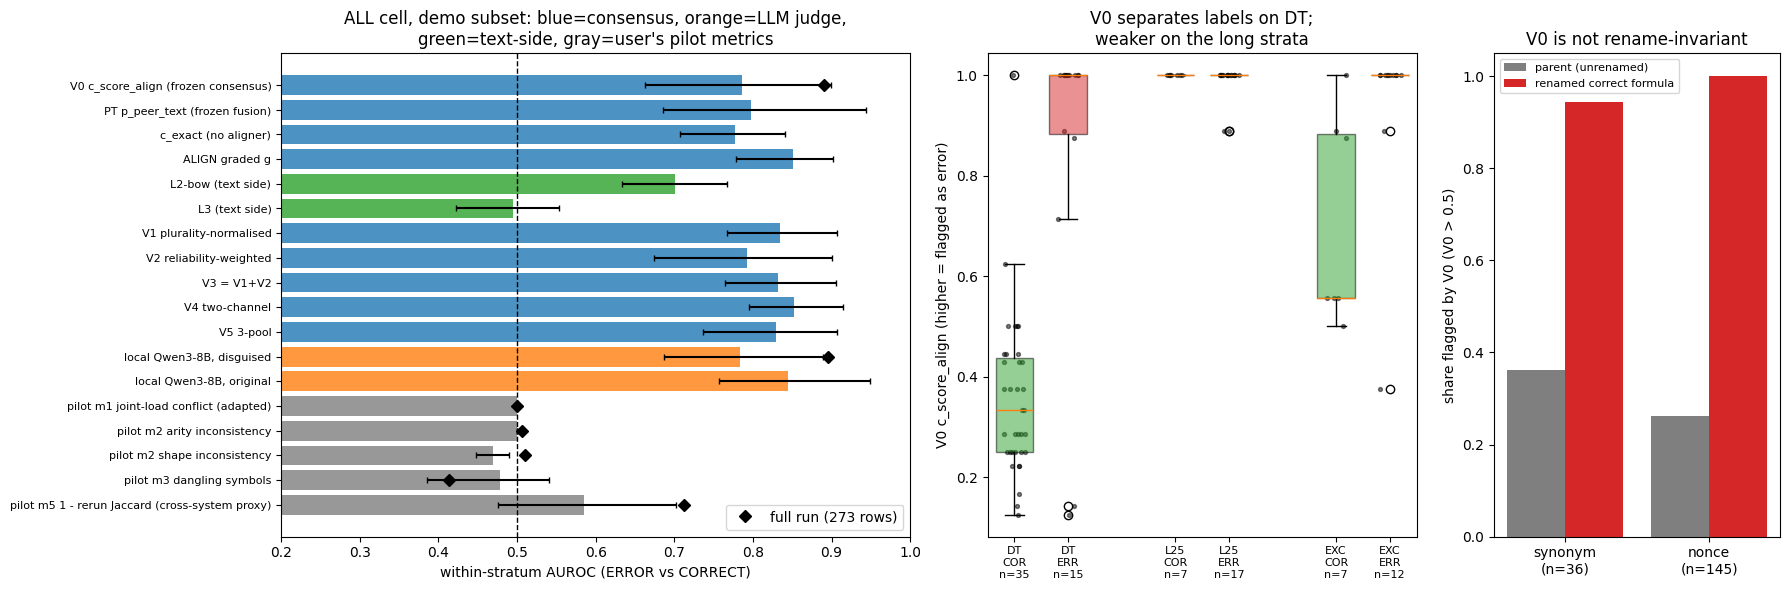

In [15]:
ref = data["full_run_reference"]
summary = pd.DataFrame([
    {"quantity": "V0 strat AUROC", **{c: out[c]["V0"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "local Qwen3-8B judge (disg.)", **{c: out[c]["local_disg"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "delta V0 - judge", **{c: out[c]["delta_V0_minus_local"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "pilot m5 rerun-Jaccard", **{c: out[c]["pilot_rerun_jacc"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "pilot m3 dangling", **{c: out[c]["pilot_dangling"] for c in ("ALL", "DT", "LONG")}},
])
full = pd.DataFrame([
    {"quantity": "V0 strat AUROC", **{c: ref[c]["V0"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "local Qwen3-8B judge (disg.)", **{c: ref[c]["local_disg"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "delta V0 - judge", **{c: ref[c]["delta_V0_minus_local"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "pilot m5 rerun-Jaccard", **{c: ref[c]["pilot_rerun_jacc"] for c in ("ALL", "DT", "LONG")}},
    {"quantity": "pilot m3 dangling", **{c: ref[c]["pilot_dangling"] for c in ("ALL", "DT", "LONG")}},
])
print(f"DEMO SUBSET ({len(rows)} rows, {len(set(r['sid'] for r in rows))} sentences):")
print(summary.round(3).to_string(index=False))
print(f"\nFULL RUN (audit/rederive_out.json; ALL n={ref['ALL']['n']}, DT n={ref['DT']['n']}, LONG n={ref['LONG']['n']}):")
print(full.round(3).to_string(index=False))
print(f"\nRename FA: demo SYN {out['RENAME_SYN']['FA']:.2f} / NONCE {out['RENAME_NONCE']['FA']:.2f}   "
      f"full SYN {ref['RENAME_SYN']['FA']:.2f} / NONCE {ref['RENAME_NONCE']['FA']:.2f}")
print(f"Full-run placebo V0 mean {ref['placebo_shuffled']['V0_mean']:.3f}; drift-gate panel agreement {ref['drift_majority_agreement']}; "
      f"API spend ${ref['spend_usd']:.2f}")

fig, ax = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={"width_ratios": [2.2, 1.5, 1]})
# (a) AUROC per metric, ALL cell
mA = A["R_AB"]["ALL"]["metrics"]
names = [n for n in METRICS if mA.get(n, {}).get("strat") is not None]
vals = [mA[n]["strat"] for n in names]
err = np.array([[mA[n]["strat"] - mA[n]["strat_ci"][0], mA[n]["strat_ci"][1] - mA[n]["strat"]] for n in names]).T
colors = ["tab:blue" if n.startswith(("c_", "g_", "p_peer")) else "tab:orange" if n.startswith("judge") else
          "tab:gray" if n.startswith("pilot") else "tab:green" for n in names]
yy = np.arange(len(names))
ax[0].barh(yy, vals, xerr=err, color=colors, alpha=0.8, capsize=2)
fullmap = {"c_score_align": ref["ALL"]["V0"], "judge_local_qwen8b_disg": ref["ALL"]["local_disg"],
           **{p: ref["ALL"][p] for p in ("pilot_joint_conflict", "pilot_arity_incons", "pilot_shape_incons", "pilot_dangling", "pilot_rerun_jacc")}}
for i, n in enumerate(names):
    if n in fullmap:
        ax[0].plot(fullmap[n], i, "kD", ms=6, label="full run (273 rows)" if n == "c_score_align" else None)
ax[0].axvline(0.5, color="k", ls="--", lw=1)
ax[0].set_yticks(yy, [LABEL_OF[n] for n in names], fontsize=8)
ax[0].invert_yaxis()
ax[0].set_xlim(0.2, 1.0)
ax[0].set_xlabel("within-stratum AUROC (ERROR vs CORRECT)")
ax[0].set_title("ALL cell, demo subset: blue=consensus, orange=LLM judge,\ngreen=text-side, gray=user's pilot metrics")
ax[0].legend(loc="lower right")
# (b) V0 by label per stratum
pos, data_b, labs = [], [], []
for j, st in enumerate(("DT", "L25", "EXC")):
    for k, lab in enumerate(("CORRECT", "ERROR")):
        v = df[(df.stratum == st) & (df.label == lab)]["c_score_align"].dropna().values
        data_b.append(v); pos.append(j * 3 + k); labs.append(f"{st}\n{lab[:3]}\nn={len(v)}")
bp = ax[1].boxplot(data_b, positions=pos, widths=0.7, patch_artist=True)
for i, p in enumerate(bp["boxes"]):
    p.set_facecolor("tab:green" if i % 2 == 0 else "tab:red"); p.set_alpha(0.5)
for i, v in enumerate(data_b):
    ax[1].scatter(np.full(len(v), pos[i]) + np.random.default_rng(i).uniform(-0.2, 0.2, len(v)), v, s=8, color="k", alpha=0.5)
ax[1].set_xticks(pos, labs, fontsize=8)
ax[1].set_ylabel("V0 c_score_align (higher = flagged as error)")
ax[1].set_title("V0 separates labels on DT;\nweaker on the long strata")
# (c) rename controls
x = np.arange(2)
ax[2].bar(x - 0.2, [out[t]["base"] for t in ("RENAME_SYN", "RENAME_NONCE")], 0.4, label="parent (unrenamed)", color="tab:gray")
ax[2].bar(x + 0.2, [out[t]["FA"] for t in ("RENAME_SYN", "RENAME_NONCE")], 0.4, label="renamed correct formula", color="tab:red")
ax[2].set_xticks(x, [f"synonym\n(n={out['RENAME_SYN']['n']})", f"nonce\n(n={out['RENAME_NONCE']['n']})"])
ax[2].set_ylabel("share flagged by V0 (V0 > 0.5)")
ax[2].set_ylim(0, 1.05)
ax[2].set_title("V0 is not rename-invariant")
ax[2].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Reading the results.** The demo subset reproduces the full run's qualitative picture:

* **Consensus works on short sentences, much less on long ones.** V0 and its variants rank ERROR above CORRECT well on `DT`
  (≈0.84–0.94) but drop to ≈0.6 on the long `L25`/`EXC` pool. There, correct but idiosyncratic long formalizations disagree
  with their peers and get flagged (see the `L25 COR` box at V0 = 1.0).
* **Consensus ties a cheap judge.** V0 − local Qwen3-8B (disguised) is ≈0 and its CI includes 0 — same as the full run
  (DT +0.003, ALL −0.005).
* **The user's pilot structural metrics do not track correctness.** Joint-load conflict and arity/shape inconsistency sit at
  ≈0.5 in every cell. Dangling symbols is ≤0.5 on DT/ALL (inverted); its 0.69 on the long cell here rests on 5 sentences, and the
  full run gives 0.56. Rerun-Jaccard carries some signal only because it is itself a lexical cross-system agreement proxy.
* **V0 is not rename-invariant:** renaming the predicates of a correct formula gets it flagged 94% (synonym) / 100% (nonce) of
  the time. These are the full 181 controls, so the numbers equal the full run.
* The subset has only 11 sentences, so CIs are wide and point estimates differ from the full run (◆ / second table: 273 rows,
  110 sentences). For example, V1/V4 edge above V0 here, while in the full run no variant cleared the freeze gate. No cell passes
  the pre-registered testability bar, and the long cell stays **not testable** in the full run too.